In [1]:
import matplotlib.pyplot as plt
import duckdb
import pandas as pd

# Assumptions

- Data file names have not been changed and are in the project root in the output directory.
- `uv sync` has been run to create a virtual environment and jupyter is running inside it

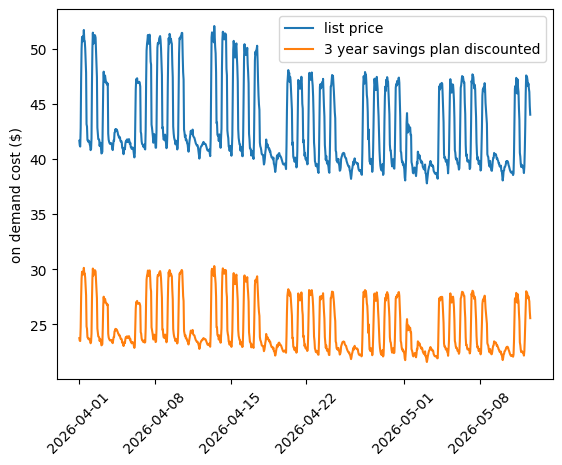

In [ ]:
stmt = """
select
    cur.timestamp
    ,sum(cur.on_demand_cost) as on_demand_cost
    ,sum(pricing.rate * cur.usage_amount) as optimized_cost
from read_parquet('../output/candidate_dataset.parquet') as cur
left join read_parquet('../output/pricing_options_filtered.parquet') as pricing on (
    cur.price_list_key = pricing.price_list_key
    and pricing.instrument_type = 'compute_savings_plan'
    and pricing.term_months = 36
)
where
    cur.commitment_key like 'AWS#Compute%'
    and cur.timestamp > '2026-04-01'
    and cur.timestamp < '2026-06-01'
group by 1
order by 1
limit 1000
"""
df = duckdb.query(stmt).df()
plt.plot(df.timestamp, df.on_demand_cost, label='list price')
plt.plot(df.timestamp, df.optimized_cost, label='3 year savings plan discounted')
plt.xticks(rotation=45)
plt.ylabel('on demand cost ($)')
plt.legend()

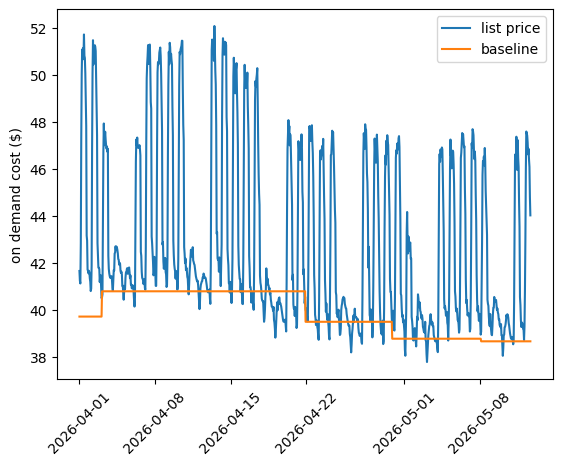

In [6]:
stmt = """
select
    cur.timestamp
    ,sum(cur.on_demand_cost) as on_demand_cost
    ,max(baseline_max) as baseline_cost
from read_parquet('../output/candidate_dataset.parquet') as cur
where
    cur.commitment_key like 'AWS#Compute%'
    and cur.timestamp > '2026-04-01'
    and cur.timestamp < '2026-06-01'
group by 1
order by 1
limit 1000
"""
df = duckdb.query(stmt).df()
plt.plot(df.timestamp, df.on_demand_cost, label='list price')
plt.plot(df.timestamp, df.baseline_cost, label='baseline')
plt.xticks(rotation=45)
plt.ylabel('on demand cost ($)')
plt.legend()